# Customer Churn & Retention Analytics

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Generative AI

**Objective:** Analyze customer churn patterns, build a simple churn-prediction baseline, and translate the findings into practical business insights.

## 1. Import Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 2. Load Dataset

The dataset is loaded from the Excel file and contains customer-level information such as tenure, contract, internet service, payment method, monthly charges, and churn status.

In [64]:
df = pd.read_excel("customer_churn.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 7,043
Columns: 33


In [65]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 3. Data Cleaning

Location fields and pre-existing churn/model fields are removed because they are outside the scope of this analysis or could introduce data leakage into the predictive model.

In [66]:
columns_to_drop = [
    "Count", "Country", "State", "City", "Zip Code",
    "Lat Long", "Latitude", "Longitude",
    "Churn Value", "Churn Score", "CLTV", "Churn Reason"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(
    df["Monthly Charges"] * df["Tenure Months"]
)

print(f"Final shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Final shape: (7043, 21)
Missing values: 0
Duplicate rows: 0


## 4. Key Performance Indicators

In [67]:
total_customers = df["CustomerID"].nunique()
churned_customers = (df["Churn Label"] == "Yes").sum()
retained_customers = (df["Churn Label"] == "No").sum()
churn_rate = churned_customers / total_customers * 100
avg_tenure = df["Tenure Months"].mean()
avg_monthly_charges = df["Monthly Charges"].mean()
total_customer_charges = df["Total Charges"].sum()

print("===== CUSTOMER CHURN KPIs =====")
print(f"Total Customers          : {total_customers:,}")
print(f"Churned Customers        : {churned_customers:,}")
print(f"Retained Customers       : {retained_customers:,}")
print(f"Churn Rate               : {churn_rate:.2f}%")
print(f"Average Tenure           : {avg_tenure:.2f} months")
print(f"Average Monthly Charges  : ${avg_monthly_charges:.2f}")
print(f"Total Customer Charges   : ${total_customer_charges:,.2f}")

===== CUSTOMER CHURN KPIs =====
Total Customers          : 7,043
Churned Customers        : 1,869
Retained Customers       : 5,174
Churn Rate               : 26.54%
Average Tenure           : 32.37 months
Average Monthly Charges  : $64.76
Total Customer Charges   : $16,056,168.70


## 5. Exploratory Churn Analysis

### Overall Churn Distribution

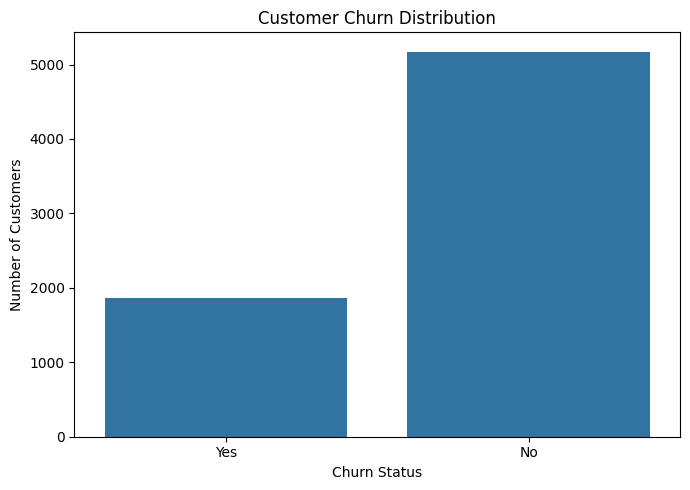

In [68]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn Label")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Churn by Contract Type

In [69]:
contract_churn_rate = (
    df.groupby("Contract")["Churn Label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(contract_churn_rate.round(2))

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn Label, dtype: float64


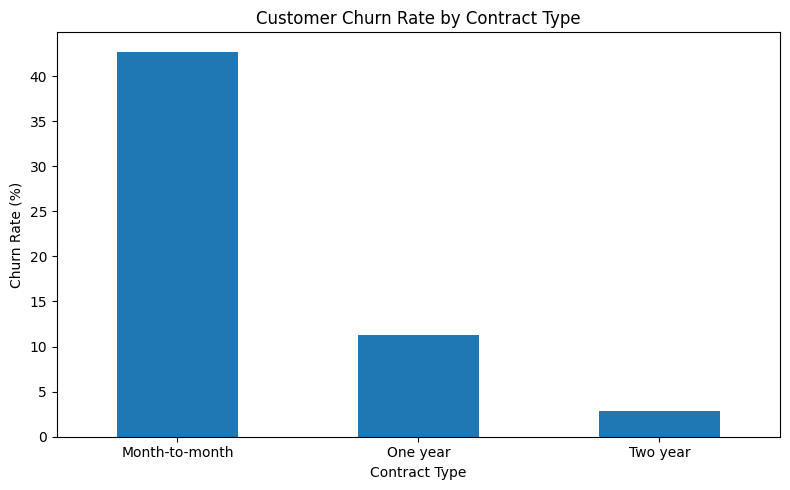

In [70]:
plt.figure(figsize=(8, 5))
contract_churn_rate.plot(kind="bar")
plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Churn by Customer Tenure

In [71]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0–6 Months", "7–12 Months", "13–24 Months", "25–48 Months", "49–72 Months"],
    include_lowest=True
)

tenure_churn = (
    df.groupby("Tenure Group", observed=True)["Churn Label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_churn.round(2))

Tenure Group
0–6 Months      52.94
7–12 Months     35.89
13–24 Months    28.71
25–48 Months    20.39
49–72 Months     9.51
Name: Churn Label, dtype: float64


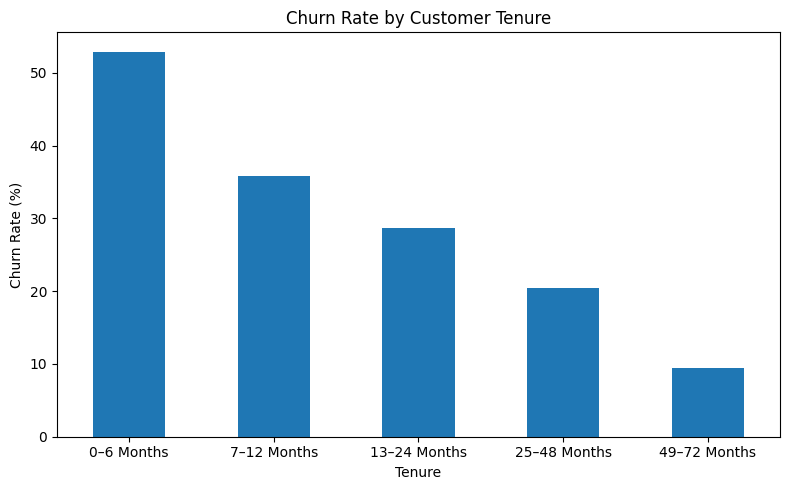

In [72]:
plt.figure(figsize=(8, 5))
tenure_churn.plot(kind="bar")
plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Churn by Internet Service

Internet Service
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn Label, dtype: float64


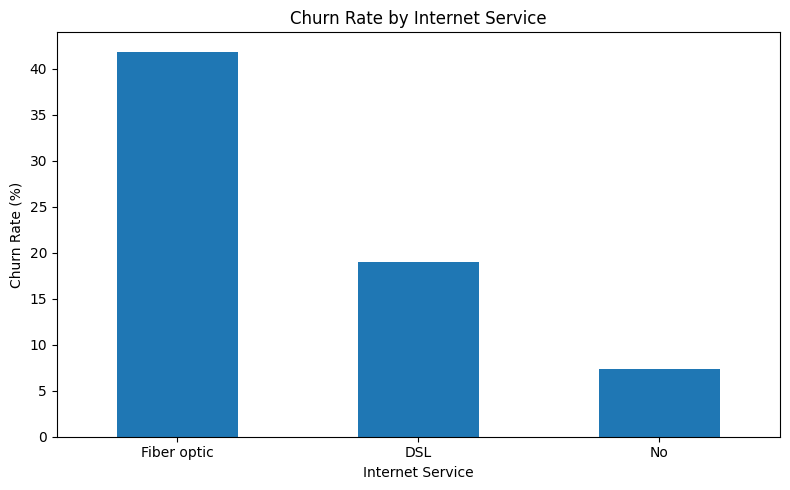

In [73]:
internet_churn = (
    df.groupby("Internet Service")["Churn Label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(internet_churn.round(2))

plt.figure(figsize=(8, 5))
internet_churn.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Churn by Payment Method

Payment Method
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn Label, dtype: float64


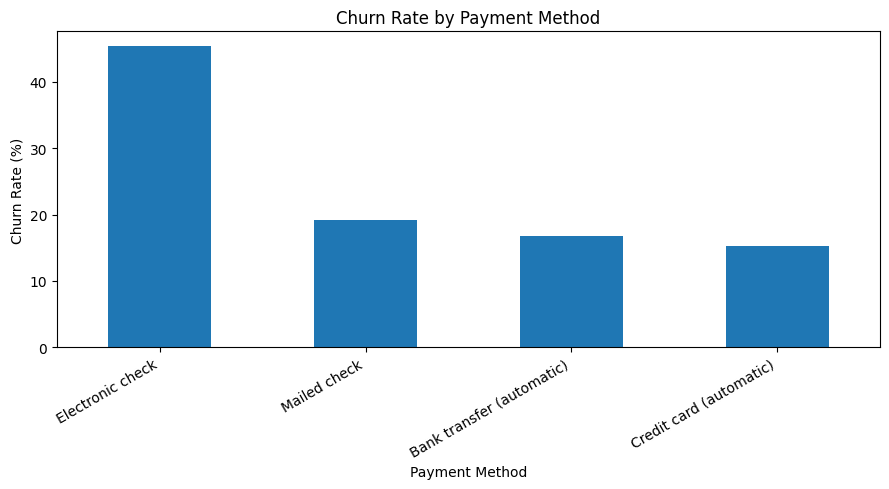

In [74]:
payment_churn = (
    df.groupby("Payment Method")["Churn Label"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(payment_churn.round(2))

plt.figure(figsize=(9, 5))
payment_churn.plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Monthly Charges by Churn Status

              mean  median
Churn Label               
No           61.27   64.43
Yes          74.44   79.65


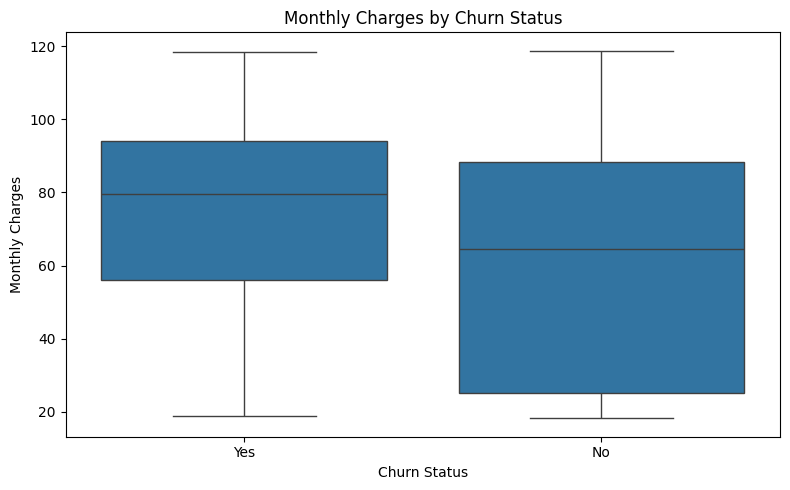

In [75]:
monthly_charge_analysis = (
    df.groupby("Churn Label")["Monthly Charges"]
    .agg(["mean", "median"])
)

print(monthly_charge_analysis.round(2))

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn Label", y="Monthly Charges")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

Correlation shows the strength and direction of linear association. It does **not** establish causation.

                 Tenure Months  Monthly Charges  Total Charges  Churn Numeric
Tenure Months             1.00             0.25           0.83          -0.35
Monthly Charges           0.25             1.00           0.65           0.19
Total Charges             0.83             0.65           1.00          -0.20
Churn Numeric            -0.35             0.19          -0.20           1.00


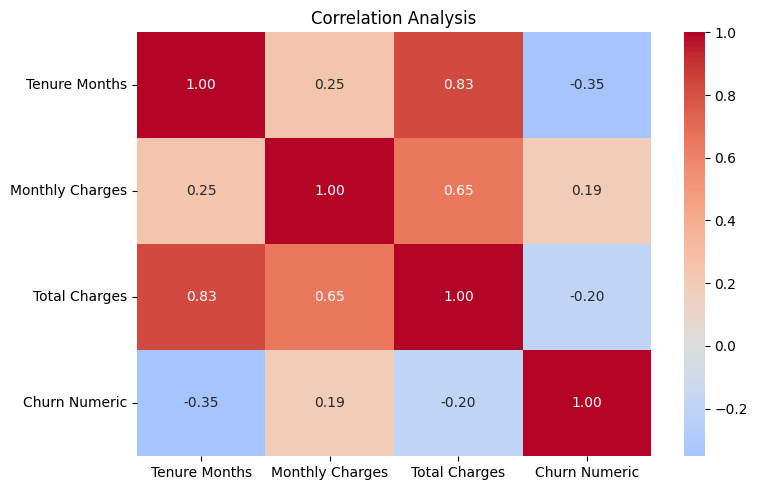

In [76]:
df["Churn Numeric"] = df["Churn Label"].map({"No": 0, "Yes": 1})

correlation = df[
    ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Numeric"]
].corr()

print(correlation.round(2))

plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Analysis")
plt.tight_layout()
plt.show()

## 7. Simple Machine Learning Model

A Logistic Regression model is used as a small predictive component. The goal is to demonstrate a basic predictive workflow, not to build a production churn system.

Fields such as **Churn Score, Churn Reason, and Churn Value** are excluded because they are directly related to the target and could cause data leakage.

In [77]:
ml_features = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Tenure Months", "Internet Service", "Contract",
    "Payment Method", "Monthly Charges", "Total Charges"
]

X = df[ml_features]
y = df["Churn Numeric"]

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_features = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Internet Service", "Contract", "Payment Method"
]

numerical_features = [
    "Tenure Months", "Monthly Charges", "Total Charges"
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples : {len(X_test):,}")

Training samples: 5,634
Testing samples : 1,409


In [79]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("===== MODEL PERFORMANCE =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall   : {recall_score(y_test, y_pred):.2%}")
print(f"F1 Score : {f1_score(y_test, y_pred):.2%}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.2%}")

===== MODEL PERFORMANCE =====
Accuracy : 79.77%
Precision: 63.13%
Recall   : 57.22%
F1 Score : 60.03%
ROC-AUC  : 84.46%


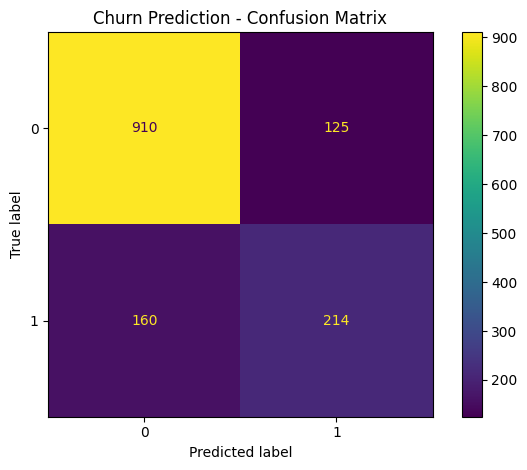

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Churn Prediction - Confusion Matrix")
plt.tight_layout()
plt.show()

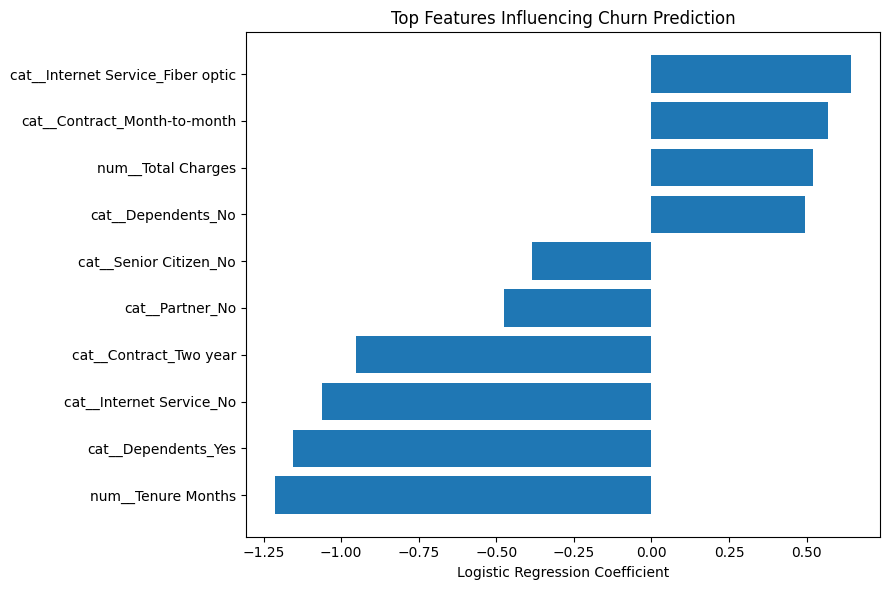

In [81]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute Coefficient"] = feature_importance["Coefficient"].abs()
top_features = (
    feature_importance
    .sort_values("Absolute Coefficient", ascending=False)
    .head(10)
    .sort_values("Coefficient")
)

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top Features Influencing Churn Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

## 8. AI-Assisted Insights

Generative AI was used to interpret the analytical and machine-learning results and translate them into concise business insights. The AI was given summarized results rather than raw customer-level data.

**AI did not calculate the statistics or replace the predictive model.**

In [82]:
ai_summary = f"""
CUSTOMER CHURN ANALYSIS

Overall:
- Total customers: {total_customers:,}
- Churned customers: {churned_customers:,}
- Churn rate: {churn_rate:.2f}%

KEY FINDINGS:
- Contract churn rates: {contract_churn_rate.round(2).to_dict()}
- Tenure churn rates: {tenure_churn.round(2).to_dict()}
- Internet service churn rates: {internet_churn.round(2).to_dict()}
- Payment method churn rates: {payment_churn.round(2).to_dict()}
- Monthly charge statistics: {monthly_charge_analysis.round(2).to_dict()}
- Correlation with churn: {correlation["Churn Numeric"].round(2).to_dict()}

MODEL:
- Logistic Regression
- Precision: {precision_score(y_test, y_pred):.2%}
- Recall: {recall_score(y_test, y_pred):.2%}
- F1 Score: {f1_score(y_test, y_pred):.2%}
- ROC-AUC: {roc_auc_score(y_test, y_prob):.2%}
"""

print(ai_summary)


CUSTOMER CHURN ANALYSIS

Overall:
- Total customers: 7,043
- Churned customers: 1,869
- Churn rate: 26.54%

KEY FINDINGS:
- Contract churn rates: {'Month-to-month': 42.71, 'One year': 11.27, 'Two year': 2.83}
- Tenure churn rates: {'0–6 Months': 52.94, '7–12 Months': 35.89, '13–24 Months': 28.71, '25–48 Months': 20.39, '49–72 Months': 9.51}
- Internet service churn rates: {'Fiber optic': 41.89, 'DSL': 18.96, 'No': 7.4}
- Payment method churn rates: {'Electronic check': 45.29, 'Mailed check': 19.11, 'Bank transfer (automatic)': 16.71, 'Credit card (automatic)': 15.24}
- Monthly charge statistics: {'mean': {'No': 61.27, 'Yes': 74.44}, 'median': {'No': 64.43, 'Yes': 79.65}}
- Correlation with churn: {'Tenure Months': -0.35, 'Monthly Charges': 0.19, 'Total Charges': -0.2, 'Churn Numeric': 1.0}

MODEL:
- Logistic Regression
- Precision: 63.13%
- Recall: 57.22%
- F1 Score: 60.03%
- ROC-AUC: 84.46%



### AI Prompt

Use the generated summary above with a generative AI tool:

> You are a business data analyst. Analyze the provided customer churn results. Give three key business insights, three areas the company should investigate, and three practical retention recommendations. Use only the provided findings, do not invent statistics, and do not claim that correlation or model coefficients prove causation. Keep the answer concise and professional.

## 9. Business Recommendations

1. **Focus on early-tenure customers**  
   Customers with shorter tenure show higher churn rates. Strengthen onboarding, early engagement, and customer support during the first year.

2. **Review month-to-month customers**  
   Month-to-month customers show substantially higher churn than longer-term customers. Investigate retention offers, service experience, and contract preferences.

3. **Investigate fiber-optic customer experience**  
   Fiber-optic customers show the highest observed churn rate among internet-service groups. Review pricing, service quality, installation, and support.

4. **Examine electronic-check customers**  
   Electronic-check users show the highest observed churn rate among payment methods. Investigate whether payment experience or other customer characteristics explain this pattern.

5. **Monitor higher-charge customers**  
   Churned customers have higher typical monthly charges. Review perceived value, pricing, and service usage among these customers.

These recommendations identify areas to investigate; the observed relationships do not by themselves establish causation.

## 10. Conclusion

This project analyzed customer churn using Python-based data cleaning, exploratory analysis, visualization, correlation analysis, and a simple Logistic Regression model.

The analysis found substantially higher churn among month-to-month customers and customers with shorter tenure. Fiber-optic customers and electronic-check users also showed comparatively high churn rates. Churned customers had higher typical monthly charges in this dataset.

The Logistic Regression model provided a baseline predictive component and was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Feature coefficients were used to understand which variables were most associated with the model's churn predictions.

Finally, Generative AI was used to interpret the analytical and model results and convert them into practical business recommendations.

**Overall, the project demonstrates an end-to-end workflow from raw customer data to analytical, predictive, and AI-assisted business insights.**